In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import scorecardpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn import linear_model, metrics
import re
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
##import cleaned dataset
df = pd.read_csv("final_application_data.csv")
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (173647, 81)


In [3]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_11,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AGE_YEARS,EMP_YEARS,TOTAL_ENQUIRIES,BUREAU_RECORD_COUNT,BUREAU_RECENT_CREDIT,BUREAU_AVG_CREDIT_AGE,BUREAU_MEAN_OVERDUE_DAYS,BUREAU_EARLIEST_ENDDATE,BUREAU_LATEST_ENDDATE,BUREAU_LATEST_CLOSED,BUREAU_MAX_AMT_OVERDUE,BUREAU_MAX_PROLONGATIONS,BUREAU_MAX_CREDIT,BUREAU_MEAN_DEBT,BUREAU_TOTAL_LIMIT,BUREAU_TOTAL_AMT_OVERDUE,BUREAU_CREDIT_TYPE_COUNT,BUREAU_OLDEST_UPDATE,BUREAU_TOTAL_ANNUITY,BUREAU_TYPE_CREDIT_CARD,BUREAU_TYPE_MICROLOAN,BUREAU_TYPE_MORTGAGE,BUREAU_TYPE_OTHER,HAS_NO_CLOSED_CREDIT,HAS_NO_ENDDATE,BUREAU_DEBT_UTIL,BUREAU_AVG_PROLONGATIONS,BUREAU_ACTIVE_RATE,BUREAU_BAD_SOLD_RATE,LTV_RATIO,ANNUITY_INCOME_RATIO,DEBT_TO_ANNUITY,DEF_RATE_60,BUREAU_CONSUMER_CREDIT_RATE
count,173647.00,173647.00,173647.00,173646.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,137453.00,173646.00,146758.00,146758.00,146758.00,146758.00,145467.00,145467.00,127665.00,146757.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,104787.00,146758.00,146758.00,146758.00,173647.00,173647.00,173647.00,173647.00,146758.00
mean,278124.14,0.09,0.37,154495.06,26935.99,0.02,-5173.83,-2995.62,0.79,0.21,1.00,0.28,0.05,2.05,12.00,0.01,0.04,0.08,0.21,-956.41,0.00,0.82,0.00,0.02,0.11,0.04,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,44.65,6.71,2.18,5.44,-492.25,-1071.62,1.17,-993.63,4315.99,-536.75,4380.50,0.04,728552.29,126321.02,21319.43,245.41,1.66,-1157.90,17746.33,1.29,0.04,0.05,0.01,0.13,0.01,4.58,0.01,0.41,0.00,1.14,0.19,21.90,0.05,0.74
std,102748.19,0.29,0.69,80982.38,13364.64,0.01,3586.91,1502.46,0.41,0.40,0.02,0.45,0.22,0.50,3.27,0.12,0.21,0.27,0.41,820.15,0.01,0.39,0.01,0.12,0.31,0.19,0.07,0.06,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,11.79,6.70,2.27,4.33,545.02,568.31,27.93,2593.13,9368.53,544.43,63151.30,0.23,1340609.49,426114.67,86236.31,17787.16,0.56,828.90,340235.87,1.48,0.53,0.24,0.13,0.34,0.09,1.25,0.07,0.31,0.04,0.12,0.10,8.05,0.20,0.27
min,100002.00,0.00,0.00,25650.00,1615.50,0.00,-23738.00,-7197.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-4173.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21.00,0.00,0.00,1.00,-2922.00,-2922.00,0.00,-4736.00,-2858.00,-2887.00,0.00,0.00,0.00,-684441.18,0.00,0.00,1.00,-2917.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,8.04,0.00,0.00
25%,189120.00,0.00,0.00,103500.00,17374.50,0.01,-7796.00,-4291.00,1.00,0.00,1.00,0.00,0.00,2.00,10.00,0.00,0.00,0.00,0.00,-1560.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,34.80,2.10,0.00,2.00,-626.00,-1424.83,0.00,-2133.00,84.00,-730.00,0.00,0.00,157500.00,0.00,0.00,0.00,1.00,-1897.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00,0.19,0.00,1.00,0.13,15.27,0.00,0.60
50%,278191.00,0.00,0.00,135000.00,24984.00,0.02,-4677.00,-3242.00,1.00,0.00,1.00,0.00,0.00,2.00,12.00,0.00,0.00,0.00,0.00,-758.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.50,4.50,2.00,4.00,-297.00,-1034.00,0.00,-1270.00,852.00,-351

## Fine Classing

In [4]:
# 1. Feature Selection & Data Preparation
# Exclude identifiers and the target itself
target = 'TARGET'
#feature_cols = [df_col for df_col in df.columns if df_col != target and df_col != 'SK_ID_CURR']
feature_cols = ['DEBT_TO_ANNUITY',
 'EMP_YEARS',
 'BUREAU_AVG_CREDIT_AGE',
 'AGE_YEARS',
 'BUREAU_ACTIVE_RATE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE',
 'LTV_RATIO',
 'BUREAU_RECENT_CREDIT',
 'BUREAU_OLDEST_UPDATE',
 'NAME_INCOME_TYPE',
 'BUREAU_EARLIEST_ENDDATE',
 'BUREAU_MEAN_DEBT',
 'DAYS_LAST_PHONE_CHANGE',
 'DAYS_ID_PUBLISH',
 'BUREAU_LATEST_ENDDATE',
 'REGION_RATING_CLIENT_W_CITY',
 'BUREAU_LATEST_CLOSED',
 'FLAG_EMP_PHONE',
 'REG_CITY_NOT_WORK_CITY'] ##reduce features for faster loading
print("columns excluded:" + ", ".join([col for col in df.columns if col not in feature_cols]))

# Prepare data: ensure 'Missing' is treated as NaN for scorecardpy
df_processed = df[feature_cols + [target]].copy()
df_processed = df_processed.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_processed[target] = pd.to_numeric(df_processed[target], errors='coerce')
df_processed = df_processed.dropna(subset=[target])
df_processed[target] = df_processed[target].astype(int)


# 2. Target Distribution Check
goods = (df_processed[target] == 0).sum()
bads = (df_processed[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_processed):.2%}")

# 3. Perform Fine Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING FINE CLASSING (Minimum 20 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_processed,
        y=target,
        min_num_bins=20,        # Force fine granularity
        stop_limit=0.0001,      # Smallest IV gain to keep splitting
        count_distr_limit=0.02, # Allow bins as small as 2% of total
        bin_num_limit=50,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# 4. Extract IV Summary
# scorecardpy stores total IV for each variable within each variable's binning dataframe
iv_list = []
for var, df_bin in bins.items():
    if df_bin is not None and not df_bin.empty:
        iv_val = df_bin['total_iv'].iloc[0]
        iv_list.append({
            'Variable': var,
            'IV': iv_val,
            'Bins': len(df_bin)
        })

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

print("\nVariable IV Summary:")
display(iv_df.head(30))

columns excluded:SK_ID_CURR, TARGET, FLAG_OWN_REALTY, CNT_CHILDREN, AMT_INCOME_TOTAL, AMT_ANNUITY, NAME_TYPE_SUITE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, REGION_POPULATION_RELATIVE, DAYS_REGISTRATION, FLAG_WORK_PHONE, FLAG_CONT_MOBILE, FLAG_PHONE, FLAG_EMAIL, WEEKDAY_APPR_PROCESS_START, HOUR_APPR_PROCESS_START, REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, REG_CITY_NOT_LIVE_CITY, FLAG_DOCUMENT_2, FLAG_DOCUMENT_3, FLAG_DOCUMENT_4, FLAG_DOCUMENT_5, FLAG_DOCUMENT_6, FLAG_DOCUMENT_8, FLAG_DOCUMENT_9, FLAG_DOCUMENT_11, FLAG_DOCUMENT_13, FLAG_DOCUMENT_14, FLAG_DOCUMENT_15, FLAG_DOCUMENT_16, FLAG_DOCUMENT_17, FLAG_DOCUMENT_18, FLAG_DOCUMENT_19, FLAG_DOCUMENT_20, FLAG_DOCUMENT_21, TOTAL_ENQUIRIES, BUREAU_RECORD_COUNT, BUREAU_MEAN_OVERDUE_DAYS, BUREAU_MAX_AMT_OVERDUE, BUREAU_MAX_PROLONGATIONS, BUREAU_MAX_CREDIT, BUREAU_TOTAL_LIMIT, BUREAU_TOTAL_AMT_OVERDUE, BUREAU_CREDIT_TYPE_COUNT, BUREAU_TOTAL_ANNUITY, BUREAU_TYPE_CREDIT_CARD, BUREAU_TYPE_MICROLOAN, BUREAU_TYPE

,Variable,IV,Bins
0,DEBT_TO_ANNUITY,0.19,21
1,EMP_YEARS,0.13,22
2,BUREAU_AVG_CREDIT_AGE,0.13,22
3,AGE_YEARS,0.11,30
4,BUREAU_ACTIVE_RATE,0.10,15
5,OCCUPATION_TYPE,0.09,11
6,ORGANIZATION_TYPE,0.09,15
7,LTV_RATIO,0.08,15
8,BUREAU_RECENT_CREDIT,0.08,19
9,BUREAU_OLDEST_UPDATE,0.07,22


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Extract IV values and Bin Statistics
# ─────────────────────────────────────────────────────────────────────────────

# Extract IV values for all variables using your 'bins' dictionary
iv_summary = {}
woe_details = {}

for var_name, bin_info in bins.items():
    # scorecardpy repeats the total_iv in every row of the binning dataframe
    if isinstance(bin_info, pd.DataFrame) and 'total_iv' in bin_info.columns:
        iv_value = bin_info['total_iv'].iloc[0] if not bin_info.empty else 0
    else:
        iv_value = 0
    
    iv_summary[var_name] = iv_value
    woe_details[var_name] = bin_info

# Create IV summary DataFrame
iv_df = pd.DataFrame({
    'Variable': list(iv_summary.keys()),
    'IV': list(iv_summary.values())
}).sort_values('IV', ascending=False).reset_index(drop=True)

print(f"\n✓ IV values extracted for {len(iv_summary)} variables")
print(f"\nTop 15 variables by IV:")
print("-" * 80)
print(iv_df.head(15).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Bin Count Statistics
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 80)
print("BIN COUNT STATISTICS")
print("-" * 80)

bin_counts = []
for var_name, bin_info in bins.items():
    if isinstance(bin_info, pd.DataFrame):
        # In scorecardpy, each row in bin_info is a distinct bin
        num_bins = len(bin_info)
        bin_counts.append({'Variable': var_name, 'Num_Bins': num_bins})

bin_counts_df = pd.DataFrame(bin_counts).sort_values('Num_Bins', ascending=False)

# Identify variables that successfully reached your 'min_num_bins=20' target
vars_20plus = bin_counts_df[bin_counts_df['Num_Bins'] >= 20]
print(f"\nVariables with 20+ bins:")
print("-" * 80)
print(f"  Count: {len(vars_20plus)} variables")

if len(vars_20plus) > 0:
    print(f"\n  Top variables by bin count:")
    for idx, row in vars_20plus.head(10).iterrows():
        print(f"    - {row['Variable']}: {row['Num_Bins']} bins")

print(f"\n\nOverall Bin Summary:")
print(f"  - Mean bins per variable: {bin_counts_df['Num_Bins'].mean():.1f}")
print(f"  - Median bins per variable: {bin_counts_df['Num_Bins'].median():.1f}")
print(f"  - Max bins: {bin_counts_df['Num_Bins'].max()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed WOE for the Top Variable
# ─────────────────────────────────────────────────────────────────────────────
if not iv_df.empty:
    top_var = iv_df.iloc[0]['Variable']
    print("\n" + "=" * 80)
    print(f"WOE DETAILS FOR TOP VARIABLE: {top_var}")
    print("=" * 80)
    print(f"Total IV: {iv_df.iloc[0]['IV']:.4f}")
    
    if top_var in woe_details:
        top_var_bins = woe_details[top_var]
        # These are the standard scorecardpy columns
        display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
        available_cols = [col for col in display_cols if col in top_var_bins.columns]
        
        print(f"\nDetailed Bin breakdown:")
        print("-" * 80)
        print(top_var_bins[available_cols].to_string(index=False))

print("\n" + "=" * 80)
print("FINE CLASSING COMPLETE")
print("=" * 80)


✓ IV values extracted for 20 variables

Top 15 variables by IV:
--------------------------------------------------------------------------------
               Variable   IV
        DEBT_TO_ANNUITY 0.19
              EMP_YEARS 0.13
  BUREAU_AVG_CREDIT_AGE 0.13
              AGE_YEARS 0.11
     BUREAU_ACTIVE_RATE 0.10
        OCCUPATION_TYPE 0.09
      ORGANIZATION_TYPE 0.09
              LTV_RATIO 0.08
   BUREAU_RECENT_CREDIT 0.08
   BUREAU_OLDEST_UPDATE 0.07
       NAME_INCOME_TYPE 0.07
BUREAU_EARLIEST_ENDDATE 0.07
       BUREAU_MEAN_DEBT 0.06
 DAYS_LAST_PHONE_CHANGE 0.06
        DAYS_ID_PUBLISH 0.05

--------------------------------------------------------------------------------
BIN COUNT STATISTICS
--------------------------------------------------------------------------------

Variables with 20+ bins:
--------------------------------------------------------------------------------
  Count: 8 variables

  Top variables by bin count:
    - AGE_YEARS: 30 bins
    - DAYS_ID_PUBLISH:

## Top 15 Feature Selection

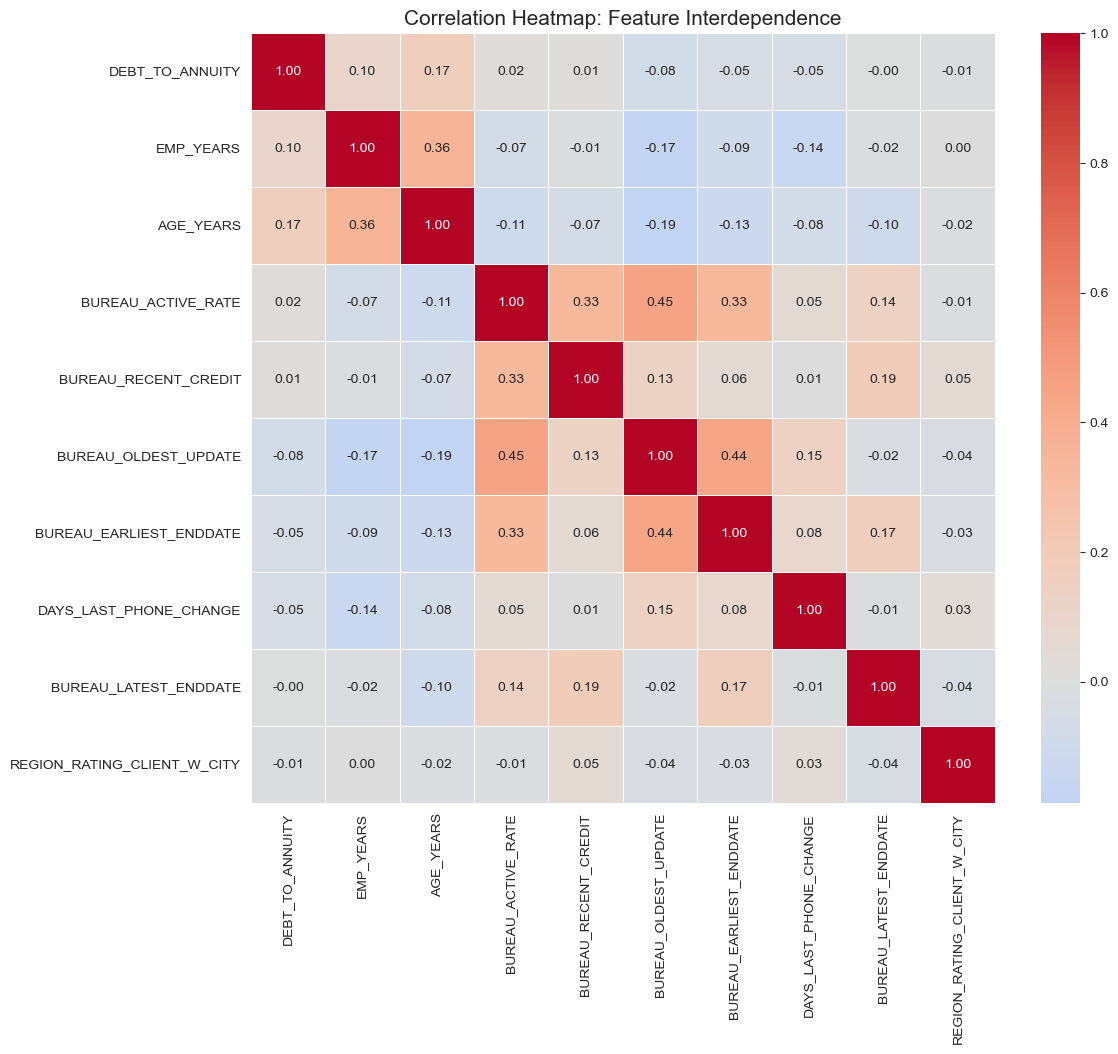

In [6]:

# Define your columns
cols_to_corr = [
    'DEBT_TO_ANNUITY', 'EMP_YEARS', 'AGE_YEARS',
    'BUREAU_ACTIVE_RATE', 'BUREAU_RECENT_CREDIT', "BUREAU_OLDEST_UPDATE", 
    "BUREAU_EARLIEST_ENDDATE", "DAYS_LAST_PHONE_CHANGE", 
    "BUREAU_LATEST_ENDDATE", "REGION_RATING_CLIENT_W_CITY"
]

# Calculate the correlation matrix
corr_matrix = df[cols_to_corr].corr()

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,           # This adds the numbers
    fmt=".2f",            # Rounds to 2 decimal places
    cmap='coolwarm',      # Blue is negative, Red is positive (ideal for correlations)
    linewidths=0.5,       # Adds small gaps between the squares
    center=0              # Centers the color map at 0
)

plt.title("Correlation Heatmap: Feature Interdependence", fontsize=15)
plt.show()

In [7]:
top15_vars = [
    'DEBT_TO_ANNUITY', 'EMP_YEARS', 'BUREAU_OLDEST_UPDATE', 'AGE_YEARS',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'BUREAU_RECENT_CREDIT', "BUREAU_EARLIEST_ENDDATE", "DAYS_LAST_PHONE_CHANGE", "REGION_RATING_CLIENT_W_CITY"
]
df_coarse = df[top15_vars + ['TARGET', 'SK_ID_CURR']].copy()
df_coarse.head()

,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_OLDEST_UPDATE,AGE_YEARS,OCCUPATION_TYPE,ORGANIZATION_TYPE,BUREAU_RECENT_CREDIT,BUREAU_EARLIEST_ENDDATE,DAYS_LAST_PHONE_CHANGE,REGION_RATING_CLIENT_W_CITY,TARGET,SK_ID_CURR
0,16.46,1.70,-1185.00,25.90,Laborers,Business Entity Type 3,-103.00,-1072.00,-1134.00,2,1,100002
1,36.23,3.30,-2131.00,45.90,Core staff,School,-606.00,-2434.00,-828.00,1,0,100003
2,10.53,8.30,NaN,52.00,Laborers,Business Entity Type 3,NaN,NaN,-617.00,2,0,100006
3,23.46,8.30,-783.00,54.60,Core staff,Religion,-1149.00,-783.00,-1106.00,2,0,100007
4,17.82,4.30,-1027.00,46.40,Laborers,Other,-78.00,-853.00,-2536.00,2,0,100008


## Coarse Classification

In [8]:
df_coarse = df_coarse.replace('Missing', np.nan)
target = "TARGET"
# Ensure target is numeric 0/1
df_coarse[target] = pd.to_numeric(df_coarse[target], errors='coerce')
df_coarse = df_coarse.dropna(subset=[target])
df_coarse[target] = df_coarse[target].astype(int)


# 2. Target Distribution Check
goods = (df_coarse[target] == 0).sum()
bads = (df_coarse[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_coarse):.2%}")

# 3. Perform Coarse Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING COARSE CLASSING (Maximum 10 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_coarse,
        y=target,
        x=top15_vars,        # Only bin the top 15 variables
        min_num_bins=2,        # Minimum 2 bins to allow for coarse classing
        stop_limit=0.1,      # Smallest IV gain to keep splitting
        count_distr_limit=0.05, # 5% minimum observations per bin
        bin_num_limit=10,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Validate and Extract Coarse Classing Results (Monotonicity fix)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)")
print("="*80)

# Define requirement thresholds
total_n = len(df_coarse)
total_bads = (df_coarse[target] == 1).sum()
total_goods = (df_coarse[target] == 0).sum()

min_obs_per_bin = int(total_n * 0.05)
min_events_per_bin = max(1, int(total_bads * 0.03)) 
min_non_events_per_bin = max(1, int(total_goods * 0.03))

validation_results = []
iv_coarse = {}
woe_details_coarse = {}

for var_name in top15_vars:
    if var_name not in bins:
        validation_results.append({
            'Variable': var_name, 'Status': 'NOT FOUND', 'Num_Bins': 0,
            'Monotonic': 'N/A', 'Failed_Requirements': 'Variable missing from bins dict'
        })
        continue
    
    bin_data = bins[var_name]
    
    # 1. Check minimum observations and events (usually includes missing)
    min_obs = bin_data['count'].min()
    min_events = bin_data['bad'].min()
    min_non_events = bin_data['good'].min()
    
    # 2. Check monotonicity - FILTER OUT 'missing' bin here
    # We only care if the trend holds for actual data ranges
    monotonic_data = bin_data[bin_data['bin'] != 'missing'].copy()
    woe_values = monotonic_data['woe'].values
    
    if len(woe_values) > 1:
        woe_diff = np.diff(woe_values)
        # Check if all differences are non-negative or all are non-positive
        is_monotonic = (np.all(woe_diff >= 0) or np.all(woe_diff <= 0))
        woe_range = monotonic_data['woe'].max() - monotonic_data['woe'].min()
    else:
        is_monotonic = True # Single data bin is technically monotonic
        woe_range = 0
    
    # 3. Check if requirements are met
    meets_obs_req = min_obs >= min_obs_per_bin
    meets_events_req = min_events >= min_events_per_bin
    meets_non_events_req = min_non_events >= min_non_events_per_bin
    
    failed_reqs = []
    if not meets_obs_req: failed_reqs.append(f"Low_Obs({min_obs})")
    if not meets_events_req: failed_reqs.append(f"Low_Bads({min_events})")
    if not meets_non_events_req: failed_reqs.append(f"Low_Goods({min_non_events})")
    if not is_monotonic: failed_reqs.append("Non-Monotonic")
    
    status = 'PASS' if not failed_reqs else 'FAIL'
    
    validation_results.append({
        'Variable': var_name,
        'Status': status,
        'Num_Bins': len(bin_data),
        'Min_Obs': min_obs,
        'Min_Bads': min_events,
        'Monotonic': 'YES' if is_monotonic else 'NO',
        'Failed_Requirements': "; ".join(failed_reqs) if failed_reqs else "None",
        'WOE_Range': round(woe_range, 4)
    })
    
    iv_coarse[var_name] = bin_data['total_iv'].iloc[0]
    woe_details_coarse[var_name] = bin_data

validation_df = pd.DataFrame(validation_results)

print("\nValidation Results (Top 15 Variables):")
print("-" * 80)
print(validation_df[['Variable', 'Status', 'Num_Bins', 'Monotonic', 'Failed_Requirements']].to_string(index=False))


Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING COARSE CLASSING (Maximum 10 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 11 columns in 00:00:10

VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)

Validation Results (Top 15 Variables):
--------------------------------------------------------------------------------
                   Variable Status  Num_Bins Monotonic Failed_Requirements
            DEBT_TO_ANNUITY   FAIL         4        NO       Non-Monotonic
                  EMP_YEARS   PASS         5       YES                None
       BUREAU_OLDEST_UPDATE   PASS         5       YES                None
                  AGE_YEARS   PASS         4       YES                None
            OCCUPATION_TYPE   PASS         5       YES                None
          ORGANIZATION_TYPE   PASS         4       YES                None
       BUREAU_RECENT_CREDIT   PASS         5       YES                None
    BUREAU_E

## WOE Plots

Plotting 10 variables


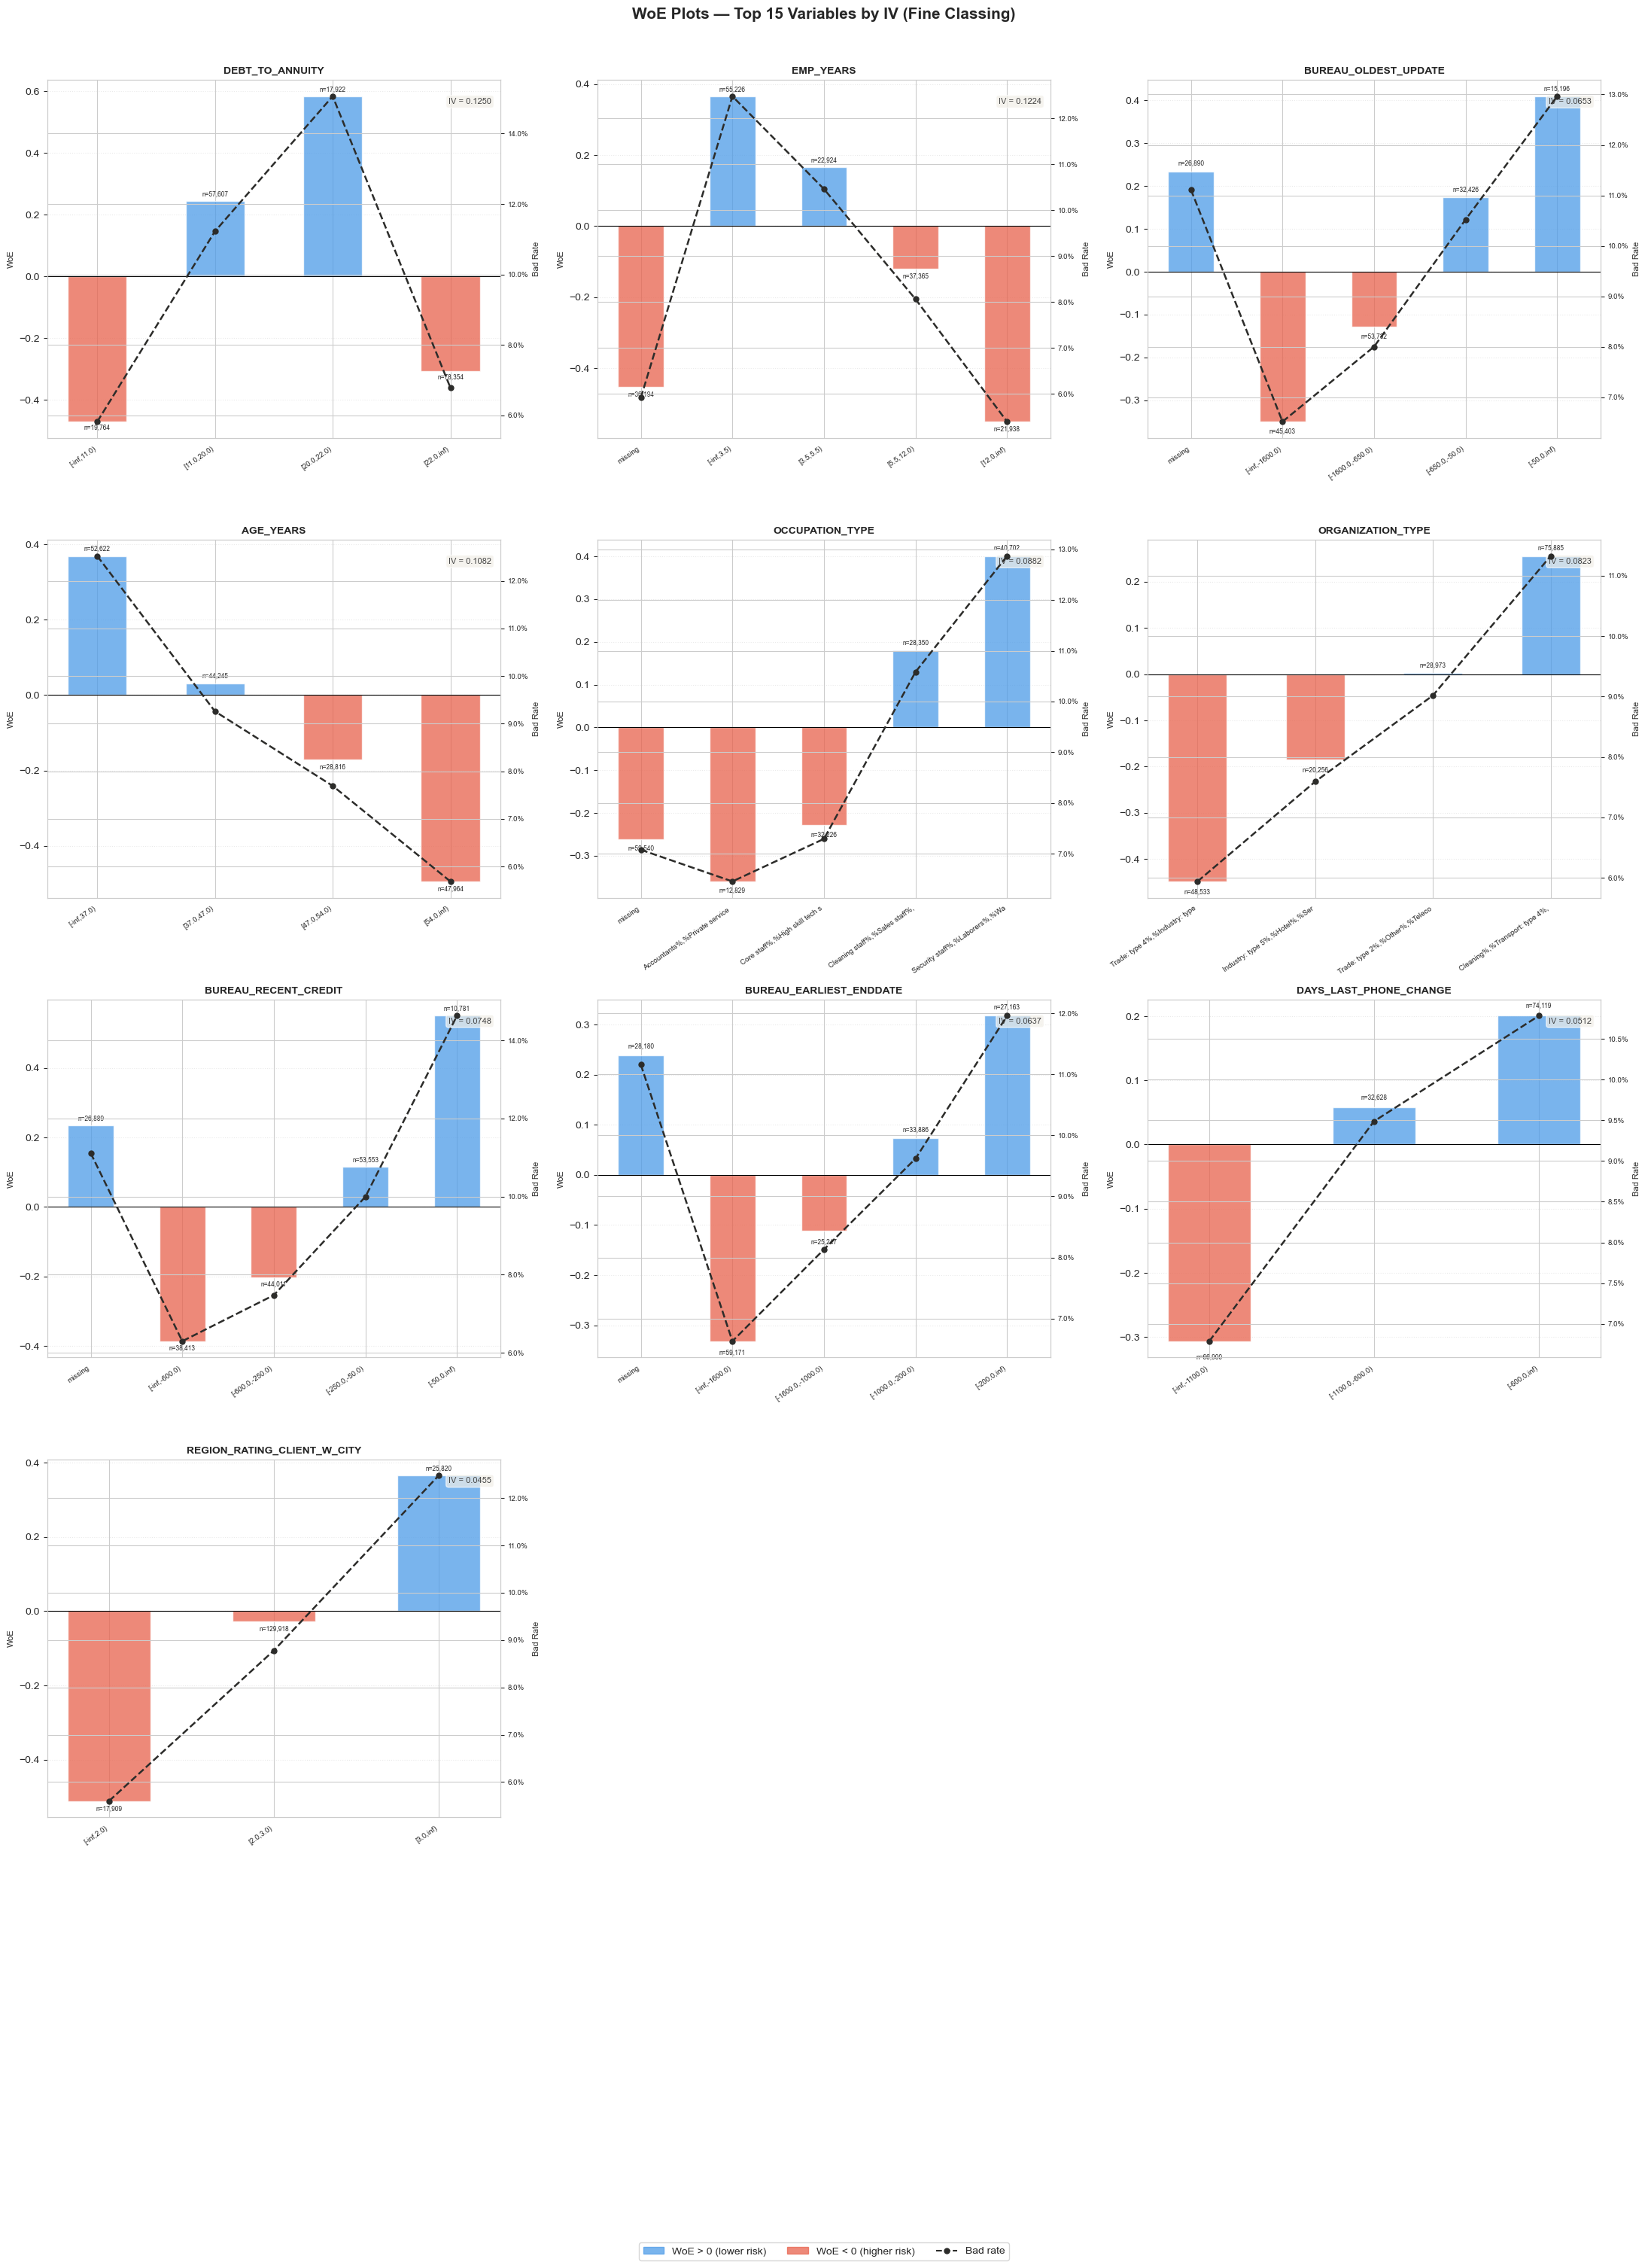

In [9]:
# Filter to variables that exist in bins_fine
vars_to_plot = [v for v in top15_vars if v in bins]
print(f"Plotting {len(vars_to_plot)} variables")

fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    bin_df = bins[var].copy()
    
    # Drop total_iv summary row if present
    if 'total_iv' in bin_df.columns:
        bin_df = bin_df[bin_df['bin'] != 'total_iv'].copy()
    
    # Shorten long bin labels for readability
    bin_df['bin_label'] = bin_df['bin'].astype(str).str[:30]
    
    x = np.arange(len(bin_df))
    woe_vals = bin_df['woe'].values
    bad_prob  = bin_df['badprob'].values if 'badprob' in bin_df.columns else None
    
    # ── Bar: WoE values ──
    colors = ['#E8624C' if w < 0 else '#4C9BE8' for w in woe_vals]
    bars = ax.bar(x, woe_vals, color=colors, alpha=0.75, width=0.5, zorder=2)
    
    # ── Line: Bad rate (secondary axis) ──
    if bad_prob is not None:
        ax2 = ax.twinx()
        ax2.plot(x, bad_prob, color='#2C2C2A', marker='o', markersize=5,
                 linewidth=1.8, linestyle='--', label='Bad rate', zorder=3)
        ax2.set_ylabel('Bad Rate', fontsize=8, color='#2C2C2A')
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%')
        )
    
    # ── Formatting ──
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_df['bin_label'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('WoE', fontsize=8)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
    
    # ── IV annotation ──
    iv_val = bins[var]['total_iv'].iloc[0] \
             if 'total_iv' in bins[var].columns else 0
    ax.annotate(f'IV = {iv_val:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=8, color='#444',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', alpha=0.7))
    
    # ── Count labels on bars ──
    if 'count' in bin_df.columns:
        for bar, cnt in zip(bars, bin_df['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01 if bar.get_height() >= 0 
                    else bar.get_height() - 0.03,
                    f'n={int(cnt):,}', ha='center', va='bottom', fontsize=6)

# Hide unused subplots
for j in range(len(vars_to_plot), len(axes)):
    axes[j].set_visible(False)

# ── Legend ──
pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.75, label='WoE > 0 (lower risk)')
neg_patch = mpatches.Patch(color='#E8624C', alpha=0.75, label='WoE < 0 (higher risk)')
bad_line  = plt.Line2D([0], [0], color='#2C2C2A', linestyle='--',
                        marker='o', markersize=5, label='Bad rate')
fig.legend(handles=[pos_patch, neg_patch, bad_line],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('WoE Plots — Top 15 Variables by IV (Fine Classing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Monotonicity Investigation

In [10]:
##investigate non-monotone variables

for var in ['DEBT_TO_ANNUITY', 'LTV_RATIO', 'BUREAU_MEAN_DEBT']:
    print(f"\n{'='*60}")
    print(f"Variable: {var}")
    print(f"{'='*60}")
    bin_df = bins[var].copy()
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'iv']
    available_cols = [c for c in display_cols if c in bin_df.columns]
    print(bin_df[available_cols].to_string(index=False))


Variable: DEBT_TO_ANNUITY
        bin  count  count_distr  good  bad  badprob   woe
[-inf,11.0)  19764         0.11 18614 1150     0.06 -0.47
[11.0,20.0)  57607         0.33 51141 6466     0.11  0.25
[20.0,22.0)  17922         0.10 15223 2699     0.15  0.58
 [22.0,inf)  78354         0.45 73040 5314     0.07 -0.31

Variable: LTV_RATIO


KeyError: 'LTV_RATIO'

In [ ]:
# breaks_adj = {
#     'LTV_RATIO'        : [1.15, 1.20],
#     'BUREAU_MEAN_DEBT' : [20000, 60000, 120_000],
# }

# # Re-bin only the 3 non-monotone variables on the full df_coarse
# bins_fixed = sc.woebin(
#     df_coarse,
#     y=target,
#     x=list(breaks_adj.keys()),
#     breaks_list=breaks_adj,
#     positive='bad|1',
#     ignore_datetime_cols=False,
#     check_cate_num=False
# )

# bins.update(bins_fixed)

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Validate and Extract Coarse Classing Results (Monotonicity fix)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)")
print("="*80)

# Define requirement thresholds
total_n = len(df_coarse)
total_bads = (df_coarse[target] == 1).sum()
total_goods = (df_coarse[target] == 0).sum()

min_obs_per_bin = int(total_n * 0.05)
min_events_per_bin = max(1, int(total_bads * 0.03)) 
min_non_events_per_bin = max(1, int(total_goods * 0.03))

validation_results = []
iv_coarse = {}
woe_details_coarse = {}

for var_name in top15_vars:
    if var_name not in bins:
        validation_results.append({
            'Variable': var_name, 'Status': 'NOT FOUND', 'Num_Bins': 0,
            'Monotonic': 'N/A', 'Failed_Requirements': 'Variable missing from bins bins dict'
        })
        continue
    
    bin_data = bins[var_name]
    
    # 1. Check minimum observations and events (usually includes missing)
    min_obs = bin_data['count'].min()
    min_events = bin_data['bad'].min()
    min_non_events = bin_data['good'].min()
    
    # 2. Check monotonicity - FILTER OUT 'missing' bin here
    # We only care if the trend holds for actual data ranges
    monotonic_data = bin_data[bin_data['bin'] != 'missing'].copy()
    woe_values = monotonic_data['woe'].values
    
    if len(woe_values) > 1:
        woe_diff = np.diff(woe_values)
        # Check if all differences are non-negative or all are non-positive
        is_monotonic = (np.all(woe_diff >= 0) or np.all(woe_diff <= 0))
        woe_range = monotonic_data['woe'].max() - monotonic_data['woe'].min()
    else:
        is_monotonic = True # Single data bin is technically monotonic
        woe_range = 0
    
    # 3. Check if requirements are met
    meets_obs_req = min_obs >= min_obs_per_bin
    meets_events_req = min_events >= min_events_per_bin
    meets_non_events_req = min_non_events >= min_non_events_per_bin
    
    failed_reqs = []
    if not meets_obs_req: failed_reqs.append(f"Low_Obs({min_obs})")
    if not meets_events_req: failed_reqs.append(f"Low_Bads({min_events})")
    if not meets_non_events_req: failed_reqs.append(f"Low_Goods({min_non_events})")
    if not is_monotonic: failed_reqs.append("Non-Monotonic")
    
    status = 'PASS' if not failed_reqs else 'FAIL'
    
    validation_results.append({
        'Variable': var_name,
        'Status': status,
        'Num_Bins': len(bin_data),
        'Min_Obs': min_obs,
        'Min_Bads': min_events,
        'Monotonic': 'YES' if is_monotonic else 'NO',
        'Failed_Requirements': "; ".join(failed_reqs) if failed_reqs else "None",
        'WOE_Range': round(woe_range, 4)
    })
    
    iv_coarse[var_name] = bin_data['total_iv'].iloc[0]
    woe_details_coarse[var_name] = bin_data

validation_df = pd.DataFrame(validation_results)

print("\nValidation Results (Top 15 Variables):")
print("-" * 80)
print(validation_df[['Variable', 'Status', 'Num_Bins', 'Monotonic', 'Failed_Requirements']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: IV Comparison (Fine vs Coarse)
# ─────────────────────────────────────────────────────────────────────────────

# Ensure iv_df exists from your previous fine classing step
iv_comparison = pd.DataFrame({
    'Variable': top15_vars,
    'IV_Fine': [iv_df[iv_df['Variable'] == var]['IV'].values[0] if var in iv_df['Variable'].values else 0 for var in top15_vars],
    'IV_Coarse': [iv_coarse.get(var, 0) for var in top15_vars]
})

iv_comparison['IV_Retained_Pct'] = (iv_comparison['IV_Coarse'] / iv_comparison['IV_Fine'] * 100).round(2)

print("\n" + "="*80)
print("IV STABILITY ANALYSIS (Fine vs Coarse)")
print("="*80)
print(iv_comparison.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed Binning for Top Coarse Variable
# ─────────────────────────────────────────────────────────────────────────────

top_var_coarse = iv_comparison.loc[iv_comparison['IV_Coarse'].idxmax(), 'Variable']
print("\n" + "="*80)
print(f"DETAILED COARSE BINNING: {top_var_coarse}")
print("="*80)

if top_var_coarse in woe_details_coarse:
    df_top = woe_details_coarse[top_var_coarse]
    # scorecardpy standard columns
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
    print(df_top[display_cols].to_string(index=False))

print("\n" + "="*80)
print("COARSE CLASSING VALIDATION COMPLETE")
print("="*80)


In [ ]:
# Filter to variables that exist in bins_fine
vars_to_plot = [v for v in top15_vars if v in bins]
print(f"Plotting {len(vars_to_plot)} variables")

fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    bin_df = bins[var].copy()
    
    # Drop total_iv summary row if present
    if 'total_iv' in bin_df.columns:
        bin_df = bin_df[bin_df['bin'] != 'total_iv'].copy()
    
    # Shorten long bin labels for readability
    bin_df['bin_label'] = bin_df['bin'].astype(str).str[:30]
    
    x = np.arange(len(bin_df))
    woe_vals = bin_df['woe'].values
    bad_prob  = bin_df['badprob'].values if 'badprob' in bin_df.columns else None
    
    # ── Bar: WoE values ──
    colors = ['#E8624C' if w < 0 else '#4C9BE8' for w in woe_vals]
    bars = ax.bar(x, woe_vals, color=colors, alpha=0.75, width=0.5, zorder=2)
    
    # ── Line: Bad rate (secondary axis) ──
    if bad_prob is not None:
        ax2 = ax.twinx()
        ax2.plot(x, bad_prob, color='#2C2C2A', marker='o', markersize=5,
                 linewidth=1.8, linestyle='--', label='Bad rate', zorder=3)
        ax2.set_ylabel('Bad Rate', fontsize=8, color='#2C2C2A')
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%')
        )
    
    # ── Formatting ──
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_df['bin_label'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('WoE', fontsize=8)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
    
    # ── IV annotation ──
    iv_val = bins[var]['total_iv'].iloc[0] \
             if 'total_iv' in bins[var].columns else 0
    ax.annotate(f'IV = {iv_val:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=8, color='#444',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', alpha=0.7))
    
    # ── Count labels on bars ──
    if 'count' in bin_df.columns:
        for bar, cnt in zip(bars, bin_df['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01 if bar.get_height() >= 0 
                    else bar.get_height() - 0.03,
                    f'n={int(cnt):,}', ha='center', va='bottom', fontsize=6)

# Hide unused subplots
for j in range(len(vars_to_plot), len(axes)):
    axes[j].set_visible(False)

# ── Legend ──
pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.75, label='WoE > 0 (lower risk)')
neg_patch = mpatches.Patch(color='#E8624C', alpha=0.75, label='WoE < 0 (higher risk)')
bad_line  = plt.Line2D([0], [0], color='#2C2C2A', linestyle='--',
                        marker='o', markersize=5, label='Bad rate')
fig.legend(handles=[pos_patch, neg_patch, bad_line],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('WoE Plots — Top 15 Variables by IV (Fine Classing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# WOE Encoding + Logistic Regression Training Model

## Train / Test Split

In [11]:
# scorecardpy split
dt_s = sc.split_df(df_coarse, y=target, ratio=0.7)

train = dt_s['train']
test = dt_s['test']

summary = pd.DataFrame({
    "Dataset": ["Overall", "Training Set", "Test Set"],
    "Number of Observations": [len(df_coarse), len(train), len(test)],
    "Bad Rates": [
        df_coarse[target].mean(),
        train[target].mean(),
        test[target].mean()
    ],
    "Bad Counts": [
        df_coarse[target].sum(),
        train[target].sum(),
        test[target].sum()
    ]
})

summary
print("Training Set - Head 10")
display(train.head(10))

print("Test Set - Head 10")
display(test.head(10))

Training Set - Head 10


,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_OLDEST_UPDATE,AGE_YEARS,OCCUPATION_TYPE,ORGANIZATION_TYPE,BUREAU_RECENT_CREDIT,BUREAU_EARLIEST_ENDDATE,DAYS_LAST_PHONE_CHANGE,REGION_RATING_CLIENT_W_CITY,TARGET,SK_ID_CURR
0,16.46,1.70,-1185.00,25.90,Laborers,Business Entity Type 3,-103.00,-1072.00,-1134.00,2,1,100002
1,36.23,3.30,-2131.00,45.90,Core staff,School,-606.00,-2434.00,-828.00,1,0,100003
2,10.53,8.30,NaN,52.00,Laborers,Business Entity Type 3,NaN,NaN,-617.00,2,0,100006
3,23.46,8.30,-783.00,54.60,Core staff,Religion,-1149.00,-783.00,-1106.00,2,0,100007
4,17.82,4.30,-1027.00,46.40,Laborers,Other,-78.00,-853.00,-2536.00,2,0,100008
6,30.81,1.90,-1991.00,27.90,Core staff,Medicine,-376.00,-2004.00,-844.00,2,0,100014
7,13.89,NaN,-904.00,55.90,NaN,XNA,-319.00,-1045.00,-2396.00,2,0,100015
8,13.75,7.40,-1367.00,36.80,Laborers,Business Entity Type 2,-128.00,-1369.00,-2370.00,2,0,100016
10,19.49,3.60,-310.00,35.40,Drivers,Government,-90.00,-311.00,-3.00,2,0,100020
11,31.00,5.60,-2287.00,31.10,Core staff,Kindergarten,-157.00,-2228.00,-1850.00,2,0,100023


Test Set - Head 10


,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_OLDEST_UPDATE,AGE_YEARS,OCCUPATION_TYPE,ORGANIZATION_TYPE,BUREAU_RECENT_CREDIT,BUREAU_EARLIEST_ENDDATE,DAYS_LAST_PHONE_CHANGE,REGION_RATING_CLIENT_W_CITY,TARGET,SK_ID_CURR
5,30.14,NaN,-2172.00,55.00,NaN,XNA,-1309.00,-2173.00,0.00,2,0,100011
9,23.60,0.60,NaN,39.90,Laborers,Transport: type 2,NaN,NaN,-188.00,1,0,100018
13,20.32,9.60,-1173.00,52.90,Cleaning staff,Business Entity Type 3,-418.00,-1173.00,0.00,2,0,100030
14,36.19,7.20,-989.00,51.30,Cooking staff,Business Entity Type 3,-75.00,-269.00,-161.00,2,1,100031
15,13.72,3.40,-652.00,43.70,Laborers,Industry: type 11,-556.00,-662.00,-2.00,2,0,100032
21,27.69,2.10,-2513.00,47.10,Private service staff,Other,-1169.00,-2453.00,-2411.00,2,0,100043
23,34.08,3.50,-1140.00,47.90,Laborers,Business Entity Type 3,-420.00,-960.00,-1075.00,2,1,100047
24,20.69,1.30,-61.00,46.50,Laborers,Industry: type 1,-75.00,-66.00,-458.00,2,0,100048
34,9.17,10.20,-425.00,33.50,NaN,University,-83.00,-1463.00,-280.00,2,0,100075
36,21.32,7.80,-1517.00,32.90,Laborers,Business Entity Type 3,-65.00,-1469.00,-1003.00,2,0,100082


## WOE Encoding

In [12]:

bins_final = sc.woebin(
    train,
    y=target,
    x=top15_vars,
    min_num_bins=2,
    max_num_bins=10,
    positive='bad|1',
    ignore_datetime_cols=False,
    check_cate_num=False,    
)

train_woe = sc.woebin_ply(train, bins_final, print_step=0)
test_woe  = sc.woebin_ply(test, bins_final, print_step=0)

print(train_woe.shape)
print(test_woe.shape)
train_woe.head()

[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
(121553, 12)
(52094, 12)


,SK_ID_CURR,TARGET,BUREAU_EARLIEST_ENDDATE_woe,REGION_RATING_CLIENT_W_CITY_woe,BUREAU_OLDEST_UPDATE_woe,EMP_YEARS_woe,DEBT_TO_ANNUITY_woe,OCCUPATION_TYPE_woe,BUREAU_RECENT_CREDIT_woe,AGE_YEARS_woe,ORGANIZATION_TYPE_woe,DAYS_LAST_PHONE_CHANGE_woe
0,100002,1,-0.10,-0.03,-0.10,0.38,0.24,0.26,0.10,0.37,0.25,-0.27
1,100003,0,-0.35,-0.50,-0.37,0.19,-0.30,-0.26,-0.38,-0.11,-0.47,0.16
2,100006,0,0.25,-0.03,0.24,-0.09,-0.45,0.26,0.24,-0.11,0.25,0.16
3,100007,0,0.01,-0.03,-0.10,-0.09,-0.30,-0.26,-0.38,-0.49,-0.47,-0.27
4,100008,0,0.01,-0.03,-0.10,0.19,0.24,0.26,0.10,-0.11,-0.01,-0.49


## Model Training

In [13]:
woe_cols = sorted([col for col in train_woe.columns if col.endswith('_woe')]) #Add a sort here to fix the problem of different column order causing masively different scorecard points
X_train = train_woe[woe_cols]
y_train = train_woe[target]

X_test = test_woe[woe_cols]
y_test = test_woe[target]

logreg = linear_model.LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    random_state=42,
)

logreg.fit(X_train, y_train)

# Extract intercept
intercept = logreg.intercept_[0]

# Create coefficient table (including intercept)
coef_df = pd.DataFrame({
    'Variable': ['Intercept'] + woe_cols,
    'Coefficient': np.concatenate([[intercept], logreg.coef_[0]])
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df

,Variable,Coefficient
10,REGION_RATING_CLIENT_W_CITY_woe,0.92
4,BUREAU_RECENT_CREDIT_woe,0.75
6,DEBT_TO_ANNUITY_woe,0.75
5,DAYS_LAST_PHONE_CHANGE_woe,0.62
8,OCCUPATION_TYPE_woe,0.54
7,EMP_YEARS_woe,0.39
1,AGE_YEARS_woe,0.32
3,BUREAU_OLDEST_UPDATE_woe,0.26
9,ORGANIZATION_TYPE_woe,0.24
2,BUREAU_EARLIEST_ENDDATE_woe,0.21


## Model Evaluation

KS Score: 0.2661


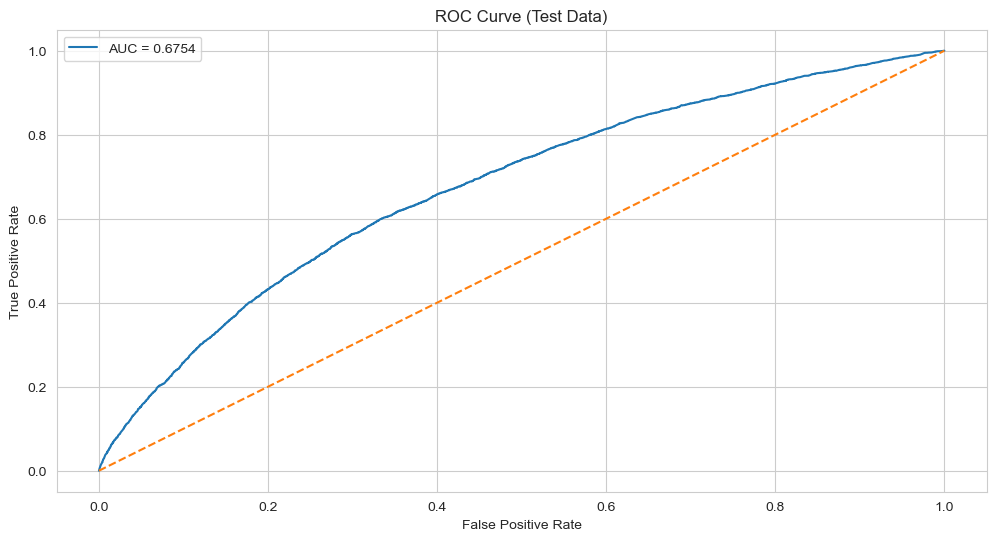

In [14]:
test_pred_prob = logreg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_pred_prob)
auc_score = roc_auc_score(y_test, test_pred_prob)

fpr, tpr, _ = roc_curve(y_test, test_pred_prob)
ks = np.max(tpr - fpr)

print(f"KS Score: {ks:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend()
plt.show()

# Scorecard

## Scorecard Creation

In [15]:
PDO = 20
TARGET_SCORE = 600
TARGET_ODDS = 1/50

card = sc.scorecard(
    bins_final,              
    logreg,
    xcolumns=top15_vars,
    points0=TARGET_SCORE,
    odds0=TARGET_ODDS,
    pdo=PDO,
    basepoints_eq0=True
)

# Combine all scorecard tables into one nice dataframe
# save current display settings
old_max_colwidth = pd.get_option('display.max_colwidth')
old_width = pd.get_option('display.width')

# set for display
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)


def clean_attribute(x):
    if pd.isna(x):
        return x
    
    x = str(x)

    # Clean scorecardpy categorical separator
    x = x.replace('%,%', ', ')
    x = x.replace('%', '')

    # Remove duplicate commas / weird spacing
    x = re.sub(r'\s*,\s*,\s*', ', ', x)
    x = re.sub(r'\s+', ' ', x).strip()

    # Round ugly float precision
    x = re.sub(r'(\d+\.\d+)', lambda m: f"{float(m.group()):.2f}", x)

    # Friendlier interval labels
    if x == 'missing':
        return 'Missing'
    if x.startswith('[-inf,'):
        upper = x.split(',')[1].replace(')', '').replace(']', '')
        return f'< {upper}'
    if x.endswith(',inf)') or x.endswith(',inf]'):
        lower = x.split(',')[0].replace('[', '').replace('(', '')
        return f'≥ {lower}'

    return x

# Build a cleaner scorecard table
dfs = []

for var, df_ in card.items():
    if var == 'basepoints':
        continue

    temp = df_[['variable', 'bin', 'points']].copy()
    temp.columns = ['Characteristic', 'Attribute', 'Points']

    temp['Attribute'] = temp['Attribute'].apply(clean_attribute)
    temp['Points'] = temp['Points'].round(0).astype(int)

    # Repeat characteristic for every row
    dfs.append(temp)

    # Visible spacer row between characteristics
    spacer = pd.DataFrame([[' ', ' ', ' ']], columns=temp.columns)
    dfs.append(spacer)

card_pretty = pd.concat(dfs, ignore_index=True)

display(
    card_pretty.style
    .hide(axis='index')
    .set_properties(subset=['Characteristic'], **{
        'text-align': 'left',
        'white-space': 'nowrap'
    })
    .set_properties(subset=['Attribute'], **{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'word-break': 'break-word',
        'max-width': '700px'
    })
    .set_properties(subset=['Points'], **{
        'text-align': 'center',
        'white-space': 'nowrap'
    })
    .set_properties(**{
        'height': '30px'
    })
)

# reset back to original display setting
pd.set_option('display.max_colwidth', old_max_colwidth)
pd.set_option('display.width', old_width)





print("Variable to coefficient mapping:")
for col, coef in zip(X_train.columns, logreg.coef_[0]):
    print(f"  {col}: {coef:.10f}")

Characteristic,Attribute,Points
DEBT_TO_ANNUITY,< 11.00,60
DEBT_TO_ANNUITY,"[11.00,20.00)",53
DEBT_TO_ANNUITY,"[20.00,22.00)",50
DEBT_TO_ANNUITY,≥ 22.00,58
,,
EMP_YEARS,Missing,58
EMP_YEARS,< 3.00,53
EMP_YEARS,"[3.00,5.50)",54
EMP_YEARS,"[5.50,11.00)",56
EMP_YEARS,≥ 11.00,58


Variable to coefficient mapping:
  AGE_YEARS_woe: 0.3157653240
  BUREAU_EARLIEST_ENDDATE_woe: 0.2051469670
  BUREAU_OLDEST_UPDATE_woe: 0.2570827708
  BUREAU_RECENT_CREDIT_woe: 0.7478263927
  DAYS_LAST_PHONE_CHANGE_woe: 0.6198518022
  DEBT_TO_ANNUITY_woe: 0.7454405509
  EMP_YEARS_woe: 0.3879692614
  OCCUPATION_TYPE_woe: 0.5382339527
  ORGANIZATION_TYPE_woe: 0.2391475004
  REGION_RATING_CLIENT_W_CITY_woe: 0.9197339337


In [16]:
# Create a list to store the range data
range_data = []

for var, df_ in card.items():
    if var == 'basepoints':
        continue
    
    # Calculate stats for the variable
    v_min = df_['points'].min()
    v_max = df_['points'].max()
    v_range = v_max - v_min
    
    range_data.append({
        'Variable': var,
        'Min Points': round(v_min, 2),
        'Max Points': round(v_max, 2),
        'Range (Swing)': round(v_range, 2)
    })

# Convert to DataFrame and sort by the biggest "Swing"
range_summary = pd.DataFrame(range_data).sort_values('Range (Swing)', ascending=False)

print("\nPOINT RANGE PER VARIABLE")
print("=" * 65)
display(range_summary.style.hide(axis='index'))


POINT RANGE PER VARIABLE


Variable,Min Points,Max Points,Range (Swing)
REGION_RATING_CLIENT_W_CITY,46.000000,69.000000,23.000000
AGE_YEARS,47.000000,66.000000,19.000000
ORGANIZATION_TYPE,50.000000,65.000000,15.000000
OCCUPATION_TYPE,46.000000,60.000000,14.000000
BUREAU_EARLIEST_ENDDATE,50.000000,61.000000,11.000000
BUREAU_RECENT_CREDIT,49.000000,60.000000,11.000000
DEBT_TO_ANNUITY,50.000000,60.000000,10.000000
BUREAU_OLDEST_UPDATE,52.000000,58.000000,6.000000
EMP_YEARS,53.000000,58.000000,5.000000
DAYS_LAST_PHONE_CHANGE,54.000000,59.000000,5.000000


## Scorecard Model Evaluation

In [17]:
train_score = sc.scorecard_ply(train, card)
test_score = sc.scorecard_ply(test, card)

Cutoff,Approved (n),Approved (%),Rejected (n),Rejected (%),Defaults in Approved,Default Rate,Defaults Captured
490,52094,100.0000%,0,0.0000%,4689,9.0010%,0.0000%
500,52093,99.9981%,1,0.0019%,4689,9.0012%,0.0000%
510,52028,99.8733%,66,0.1267%,4662,8.9606%,0.5758%
520,51252,98.3837%,842,1.6163%,4464,8.7099%,4.7985%
530,48092,92.3177%,4002,7.6823%,3837,7.9785%,18.1702%
540,41886,80.4047%,10208,19.5953%,2929,6.9928%,37.5347%
550,33488,64.2838%,18606,35.7162%,1968,5.8767%,58.0294%
560,24440,46.9152%,27654,53.0848%,1298,5.3110%,72.3182%
570,16422,31.5238%,35672,68.4762%,768,4.6767%,83.6212%
580,9118,17.5030%,42976,82.4970%,379,4.1566%,91.9173%


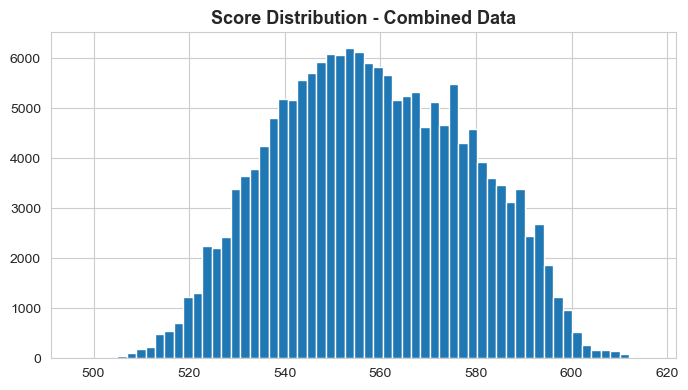

In [18]:
# Cutoff Sensitivity Analysis
scores_col = test_score.columns[0]
scores      = test_score[scores_col].values
actuals     = y_test.values

total       = len(scores)
total_bads  = actuals.sum()

cutoffs = range(
    int(scores.min() // 10) * 10,
    int(scores.max() // 10) * 10 + 20,
    10
)

rows = []
for c in cutoffs:
    approved        = (scores >= c).sum()
    rejected        = total - approved
    approved_bads   = actuals[scores >= c].sum()
    approved_goods  = approved - approved_bads


    rows.append({
    "Cutoff"              : c,
    "Approved (n)"        : approved,
    "Approved (%)"        : f"{approved / total * 100:.4f}%",
    "Rejected (n)"        : rejected,
    "Rejected (%)"        : f"{rejected / total * 100:.4f}%",
    "Defaults in Approved": approved_bads,
    "Default Rate"        : f"{approved_bads / approved * 100:.4f}%" if approved > 0 else "N/A",
    "Defaults Captured"   : f"{(total_bads - approved_bads) / total_bads * 100:.4f}%",
})

cutoff_df = pd.DataFrame(rows)

display(
    cutoff_df.style
    .hide(axis="index")
    .set_caption("Cutoff Sensitivity - Test Set")
    .set_properties(**{"text-align": "center"})
    .set_properties(subset=["Cutoff"], **{"font-weight": "bold"})
)


# Combine train and test scores
combined_score = pd.concat([train_score, test_score], ignore_index=True)

# Plot distribution of scores on combined data
combined_score.hist(figsize=(7, 4), bins=60)
plt.title('Score Distribution - Combined Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
cutoff = 570 # Set cutoff based on sensitivity analysis and business requirements

# create sets of predicted bad to compare with actual bad
predicted_bad_train = (train_score < cutoff)
predicted_bad_train_list = predicted_bad_train.astype(int).values.flatten().tolist()
predicted_bad_test = (test_score < cutoff)
predicted_bad_test_list = predicted_bad_test.astype(int).values.flatten().tolist()

print('*** Training Data Performance ***')
print('Confusion matrix:')
print(metrics.confusion_matrix(y_train, predicted_bad_train_list))
print('PCC measures:')
print(metrics.classification_report(y_train, predicted_bad_train_list))

print('*** Test Data Performance ***')
print('Confusion matrix:')
print(metrics.confusion_matrix(y_test, predicted_bad_test_list))
print('PCC measures:')
print(metrics.classification_report(y_test, predicted_bad_test_list))

*** Training Data Performance ***
Confusion matrix:
[[36262 74351]
 [ 1754  9186]]
PCC measures:
              precision    recall  f1-score   support

           0       0.95      0.33      0.49    110613
           1       0.11      0.84      0.19     10940

    accuracy                           0.37    121553
   macro avg       0.53      0.58      0.34    121553
weighted avg       0.88      0.37      0.46    121553

*** Test Data Performance ***
Confusion matrix:
[[15654 31751]
 [  768  3921]]
PCC measures:
              precision    recall  f1-score   support

           0       0.95      0.33      0.49     47405
           1       0.11      0.84      0.19      4689

    accuracy                           0.38     52094
   macro avg       0.53      0.58      0.34     52094
weighted avg       0.88      0.38      0.46     52094



=== Scorecard Metrics & Evaluation (Cutoff = 570) ===


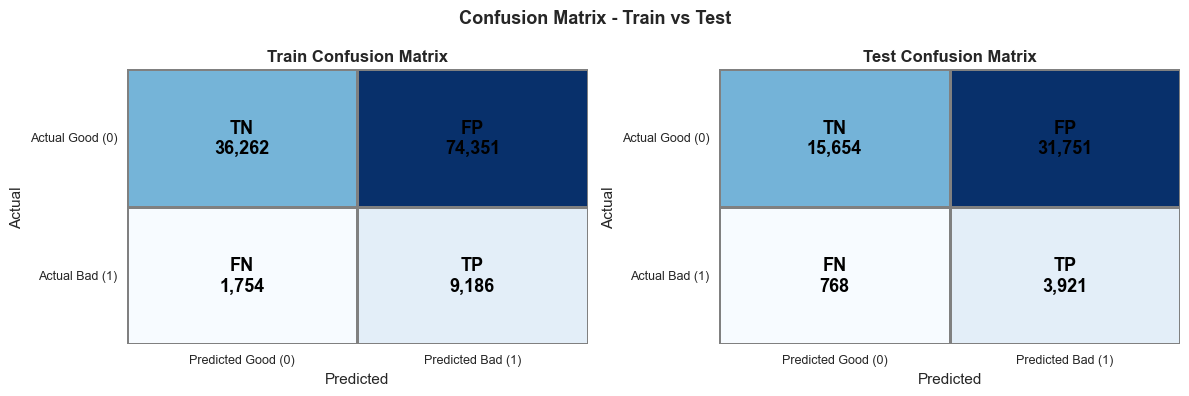

*** PCC Metrics Summary Table ***


Metric,Train,Test,Difference
Accuracy,0.3739,0.3758,0.19%
Error Rate,0.6261,0.6242,-0.19%
Precision,0.1100,0.1099,-0.01%
Recall,0.8397,0.8362,-0.35%
Specificity,0.3278,0.3302,0.24%
F1 Score,0.1945,0.1943,-0.02%




*** AUC and Gini Summary ***
Metric                    Train       Test
------------------------------------------
AUC                      0.6743     0.6754
Gini Coefficient         0.3487     0.3509


*** KS on Scorecard Scores***
Metric                              Train       Test
----------------------------------------------------
KS (logit probabilities)           0.2596     0.2661
KS (scorecard points)              0.2455     0.2475





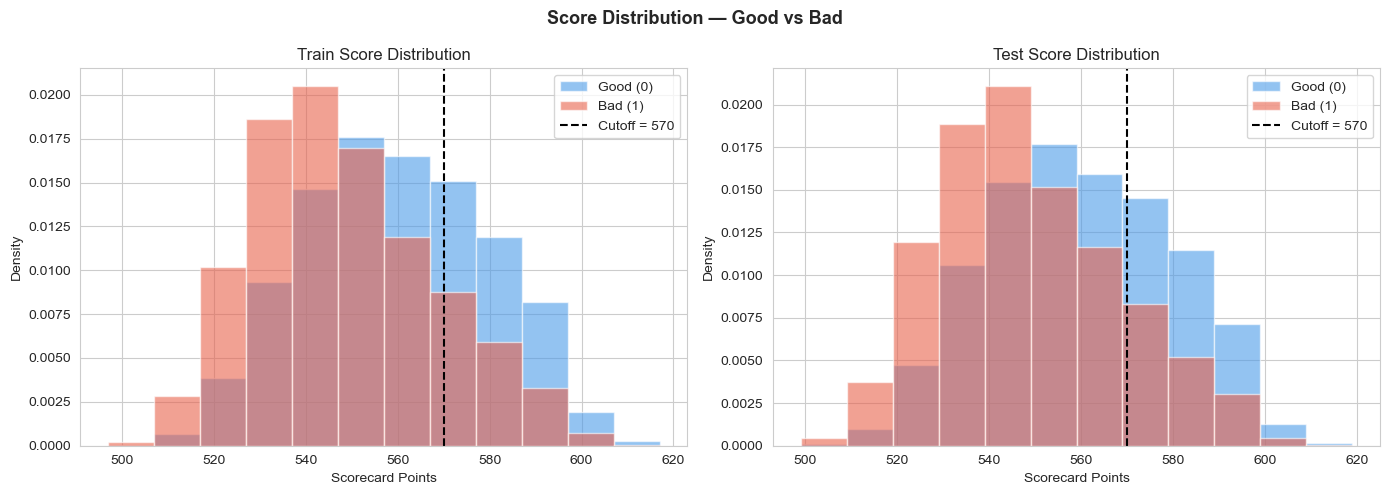

In [20]:
print(f'=== Scorecard Metrics & Evaluation (Cutoff = {cutoff}) ===')
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    error_rate  = 1 - accuracy
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'Accuracy'   : round(accuracy, 4),
        'Error Rate' : round(error_rate, 4),
        'Precision'  : round(precision, 4),
        'Recall'     : round(recall, 4),
        'Specificity': round(specificity, 4),
        'F1 Score'   : round(f1, 4),
    }

train_metrics = get_metrics(y_train, predicted_bad_train_list)
test_metrics  = get_metrics(y_test,  predicted_bad_test_list)




# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, label in [
    (axes[0], y_train, predicted_bad_train_list, 'Train'),
    (axes[1], y_test,  predicted_bad_test_list,  'Test')
]:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm, ax=ax, cmap='Blues', cbar=False,
        linewidths=1, linecolor='gray',
        annot=False
    )

    for (row, col, text) in [
        (0, 0, f'TN\n{tn:,}'),
        (0, 1, f'FP\n{fp:,}'),
        (1, 0, f'FN\n{fn:,}'),
        (1, 1, f'TP\n{tp:,}'),
    ]:
        ax.text(col + 0.5, row + 0.5, text,
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='black')

    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{label} Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Predicted Good (0)', 'Predicted Bad (1)'], fontsize=9)
    ax.set_yticklabels(['Actual Good (0)', 'Actual Bad (1)'], fontsize=9, rotation=0)

plt.suptitle('Confusion Matrix - Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




# PCC Metrics Summary Table
metrics_df = pd.DataFrame({
    'Metric': list(train_metrics.keys()),
    'Train' : list(train_metrics.values()),
    'Test'  : list(test_metrics.values()),
})

print('*** PCC Metrics Summary Table ***')
display(
    metrics_df.assign(Difference=((metrics_df['Test'] - metrics_df['Train']) * 100).round(2).astype(str) + '%').style
    .hide(axis='index')
    .format({'Train': '{:.4f}', 'Test': '{:.4f}'})
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Metric'], **{'text-align': 'left', 'font-weight': 'bold'})
)




# AUC and Gini Summary
train_pred_prob = logreg.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, train_pred_prob)
test_auc  = roc_auc_score(y_test,  test_pred_prob)

train_gini = 2 * train_auc - 1
test_gini  = 2 * test_auc  - 1

print('\n\n*** AUC and Gini Summary ***')
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'AUC':<20} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Gini Coefficient':<20} {train_gini:>10.4f} {test_gini:>10.4f}")




# KS Statistic on Scorecard Scores
def ks_from_scores(scores_df, y_true):
    scores = scores_df.iloc[:, 0].values
    df_ks = pd.DataFrame({'score': scores, 'target': y_true.values})
    df_ks = df_ks.sort_values('score')
    total_bad  = (df_ks['target'] == 1).sum()
    total_good = (df_ks['target'] == 0).sum()
    df_ks['cum_bad']  = (df_ks['target'] == 1).cumsum() / total_bad
    df_ks['cum_good'] = (df_ks['target'] == 0).cumsum() / total_good
    ks = (df_ks['cum_bad'] - df_ks['cum_good']).abs().max()
    return round(ks, 4)

# Compute KS on logit probabilities for both train and test
train_pred_prob_ks = logreg.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, train_pred_prob_ks)
ks_logit_train = np.max(tpr_train - fpr_train)
ks_logit_test  = np.max(tpr - fpr)  # tpr/fpr from test set

ks_train_score = ks_from_scores(train_score, y_train)
ks_test_score  = ks_from_scores(test_score,  y_test)

print('\n\n*** KS on Scorecard Scores***')
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)
print(f"{'KS (logit probabilities)':<30} {ks_logit_train:>10.4f} {ks_logit_test:>10.4f}")
print(f"{'KS (scorecard points)':<30} {ks_train_score:>10.4f} {ks_test_score:>10.4f}")




# Score Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores_df, y_true, label in [
    (axes[0], train_score, y_train, 'Train'),
    (axes[1], test_score,  y_test,  'Test')
]:
    scores      = scores_df.iloc[:, 0]
    good_scores = scores[y_true == 0]
    bad_scores  = scores[y_true == 1]

    bins_range = range(int(scores.min()), int(scores.max()) + 10, 10)

    ax.hist(good_scores, bins=bins_range, alpha=0.6, color='#4C9BE8', label='Good (0)', density=True)
    ax.hist(bad_scores,  bins=bins_range, alpha=0.6, color='#E8624C', label='Bad (1)',  density=True)
    ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.5, label=f'Cutoff = {cutoff}')
    ax.set_xlabel('Scorecard Points')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} Score Distribution')
    ax.legend()

print('\n\n')
plt.suptitle('Score Distribution — Good vs Bad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



Performance Trade-off Table:


,Cutoff,KS_at_Cutoff,Recall_1_Bads,Recall_0_Goods,Approval_Rate,Bad_Rate_Approved,Global_Model_KS,Model_Power_Retained
0,495,0.000000,0.000000,1.000000,1.000000,0.090000,0.245200,0.000000
1,500,0.000000,0.000000,1.000000,1.000000,0.090000,0.245200,0.000000
2,505,0.000600,0.000600,0.999900,0.999900,0.090000,0.245200,0.002400
3,510,0.004900,0.005800,0.999200,0.998700,0.089600,0.245200,0.020000
4,515,0.016200,0.020900,0.995300,0.993900,0.088700,0.245200,0.066100
5,520,0.035000,0.048000,0.987000,0.983800,0.087100,0.245200,0.142700
6,525,0.070600,0.105400,0.965300,0.958900,0.084000,0.245200,0.287900
7,530,0.115300,0.181700,0.933600,0.923200,0.079800,0.245200,0.470200
8,535,0.156200,0.270000,0.886200,0.872100,0.075300,0.245200,0.637000
9,540,0.197100,0.375300,0.821800,0.804000,0.069900,0.245200,0.803800


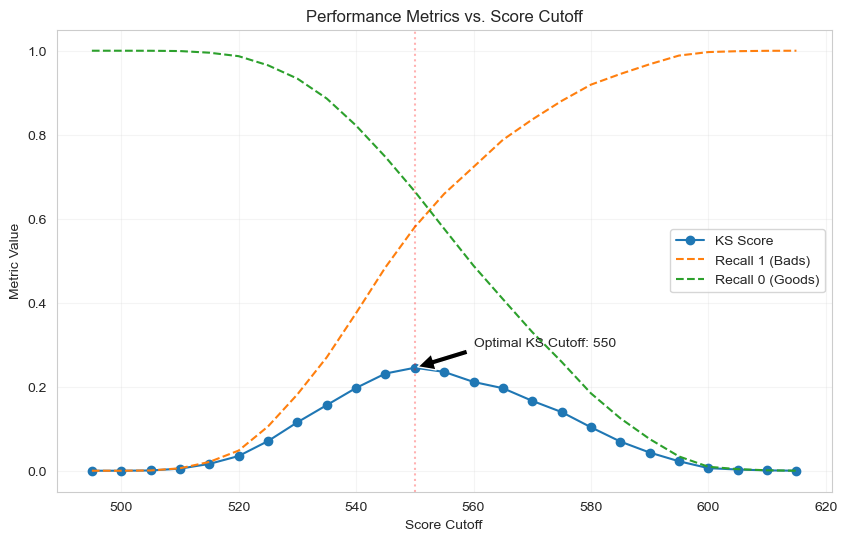

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score

def evaluate_cutoffs(scores, actual, step=5):
    """
    Generates a performance table for different credit score cutoffs.
    """
    # Force scores and actual to numpy arrays to avoid indexing/type errors
    scores = np.array(scores).flatten()
    actual = np.array(actual).flatten()
    
    min_s = int(min(scores) // step * step)
    max_s = int(max(scores) // step * step)
    cutoffs = range(min_s, max_s + step, step)
    
    results = []
    total_goods = (actual == 0).sum()
    total_bads = (actual == 1).sum()
    
    for cutoff in cutoffs:
        preds = (scores < cutoff).astype(int)
        
        # Calculate Recalls
        rec_1 = recall_score(actual, preds, pos_label=1)
        rec_0 = recall_score(actual, preds, pos_label=0)
        
        # Point-in-time KS (Separation at THIS cutoff)
        bads_caught_pct = (actual[scores < cutoff] == 1).sum() / total_bads
        goods_rejected_pct = (actual[scores < cutoff] == 0).sum() / total_goods
        ks_at_cutoff = abs(bads_caught_pct - goods_rejected_pct)
        
        results.append({
            'Cutoff': cutoff,
            'KS_at_Cutoff': round(ks_at_cutoff, 4),
            'Recall_1_Bads': round(rec_1, 4),
            'Recall_0_Goods': round(rec_0, 4),
            'Approval_Rate': round((scores >= cutoff).mean(), 4),
            'Bad_Rate_Approved': round(actual[scores >= cutoff].mean(), 4)
        })
    
    df = pd.DataFrame(results)
    
    # --- ADD GLOBAL KS ---
    # The Global Model KS is simply the highest KS score found across all cutoffs
    df['Global_Model_KS'] = df['KS_at_Cutoff'].max()
    
    # Calculate % of Model Power Retained at this cutoff
    df['Model_Power_Retained'] = (df['KS_at_Cutoff'] / df['Global_Model_KS']).round(4)
    
    return df

# --- EXECUTION ---
# Using the variable names from your notebook (y_test and test_score)
df_performance = evaluate_cutoffs(test_score.iloc[:, 0], y_test, step=5)

# Highlighting for clarity
print("Performance Trade-off Table:")
display(df_performance.style.highlight_max(subset=['KS_at_Cutoff'], color='lightgreen'))

# --- VISUALIZATION ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_performance['Cutoff'], df_performance['KS_at_Cutoff'], label='KS Score', marker='o')
plt.plot(df_performance['Cutoff'], df_performance['Recall_1_Bads'], label='Recall 1 (Bads)', linestyle='--')
plt.plot(df_performance['Cutoff'], df_performance['Recall_0_Goods'], label='Recall 0 (Goods)', linestyle='--')

# Find max KS to annotate
max_ks_row = df_performance.loc[df_performance['KS_at_Cutoff'].idxmax()]
plt.axvline(max_ks_row['Cutoff'], color='red', alpha=0.3, linestyle=':')
plt.annotate(f"Optimal KS Cutoff: {int(max_ks_row['Cutoff'])}", 
             xy=(max_ks_row['Cutoff'], max_ks_row['KS_at_Cutoff']), 
             xytext=(max_ks_row['Cutoff']+10, max_ks_row['KS_at_Cutoff']+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Performance Metrics vs. Score Cutoff')
plt.xlabel('Score Cutoff')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()